# Introduction

- Objective:
    - Generate summary figures for graph ensemble analysis
- Method:
    - Summarize the standard deviation improvement (increase) for the target feature
    - Summarize the standard deviation mean improvement (decrease) for the other features
- Input:
    - Input path: "gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis"
    - AUPRC from sensitivity analysis with each motif variation using GENIE3
    - AUROC from sensitivity analysis with each motif variation using GENIE3
    - EPR@k from sensitivity analysis with each motif variation using GENIE3 with k=size of the reference graph
- Output:
    - Outputpath: "gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis"
    - Generate Figure AUROC per motifs
    - Generate Figure AUPRC per motifs
    - Generate Figure EPR@k per motifs

# Initialization

In [1]:
# Packages
import numpy as np
import matplotlib.pyplot as plt
import gcsfs
import io


# Data are currently hard coded from the previous sensitivity analysis.
# Ultimately it has to be loaded from the actual data.

# Data
# Ratio of standard deviation change after selection of graphs
stats = {'Bi-Mutual':0.690,
 'Cascade':0.684,
 'Clique':1.044,
 'FBL':0.744,
 'FFL':0.696,
 'Fan-In':0.513,
 'Fan-Out':0.763,
 'Mutual-Cascade':0.679,
 'Mutual-In':0.659,
 'Mutual-Out':0.788,
 'Regulated-Mutual':0.613,
 'Regulating-Mutual':0.728,
 'Semi-Clique':0.630
}

# AUROC pearson correlation with the corresponding motif variation
auroc_pearson = {
    'Bi-Mutual': -0.033, 'Cascade': -0.665, 'Clique': 0.077, 'FBL': -0.044, 'FFL': -0.016,
    'Fan-In': -0.614, 'Fan-Out': 0.079, 'Mutual-Cascade': 0.070,
    'Mutual-In': -0.316, 'Mutual-Out': 0.218, 'Regulated-Mutual': 0.062,
    'Regulating-Mutual': 0.111, 'Semi-Clique': -0.083
}

# AUPRC pearson correlation with the corresponding motif variation
auprc_pearson = {
    'Bi-Mutual': 0.087, 'Cascade': -0.619, 'Clique': -0.023, 'FBL': 0.020, 'FFL': 0.500,
    'Fan-In': -0.648, 'Fan-Out': -0.517, 'Mutual-Cascade': 0.226,
    'Mutual-In': -0.041, 'Mutual-Out': 0.348, 'Regulated-Mutual': 0.0338,
    'Regulating-Mutual': 0.279, 'Semi-Clique': 0.056
}

# EPR pearson correlation with the corresponding motif variation @k corresponding to the size of the ground truth graph
epr_pearson = {
    'Bi-Mutual': 0.198, 'Cascade': -0.573, 'Clique': -0.036, 'FBL': 0.101,
    'Fan-In': -0.494, 'Fan-Out': -0.475, 'Mutual-Cascade': 0.236,
    'Mutual-In': 0.101, 'Mutual-Out': 0.324, 'Regulated-Mutual': 0.394,
    'Regulating-Mutual': 0.297, 'Semi-Clique': 0.119, 'FFL': 0.457
}

# Output
fs = gcsfs.GCSFileSystem()
DATA_BUCKET = "gs://aetl_sur-axe-workspace-prod-db34/data/"
OUTPUT_PATH = f"{DATA_BUCKET}sensitivity_analysis/"
OUTPUT_FIGURE_PATH = f"{DATA_BUCKET}sensitivity_analysis/figures/"

/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.21) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.21) which Google will stop supporting in new releases of google.cloud._storage_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud._storage_v2 past that date.
  warnings.warn(message, FutureWarning)
/opt/micromamba/envs/venv_trajinf/lib/python3.10/site-packages/goo

# Functions

In [2]:
def save_fig_to_gcs(fig, gcs_path, format, dpi=300):
    """Save matplotlib figure to GCS bucket."""
    buf = io.BytesIO()
    fig.savefig(buf, format=format, dpi=dpi, bbox_inches='tight')
    buf.seek(0)
    # Remove 'gs://' prefix if present (gcsfs handles both, but being explicit)
    with fs.open(gcs_path, 'wb') as f:
        f.write(buf.read())
    print(f"Saved: {gcs_path}")

# Check variation change

Will have to move to appropriate part. No output yet so no issue with migration

In [4]:
mean_value = np.mean(list(stats.values()))
median_value = np.median(list(stats.values()))
std_value = np.std(list(stats.values()))
cv = (std_value / mean_value)
print(f"The graph selection yielded an improvement of the target feature standard deviation by {mean_value:.2f} on average (median = {median_value:.2f}).")
print(f"The coefficient of variation reported is {cv:.2f}.")
print("Those values demonstrate that the procedure improves the target feature distribution relative to their orignal distribution.")

The graph selection yielded an improvement of the target feature standard deviation by 0.71 on average (median = 0.69).
The coefficient of variation reported is 0.17.
Those values demonstrate that the procedure improves the target feature distribution relative to their orignal distribution.


# Plot AUROC and AUPRC pearson correlation change with motif counts

Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/sensitivity_AUPRC_AUROC_grouped.png
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/sensitivity_AUPRC_AUROC_grouped.pdf
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/sensitivity_AUPRC_AUROC_grouped.svg


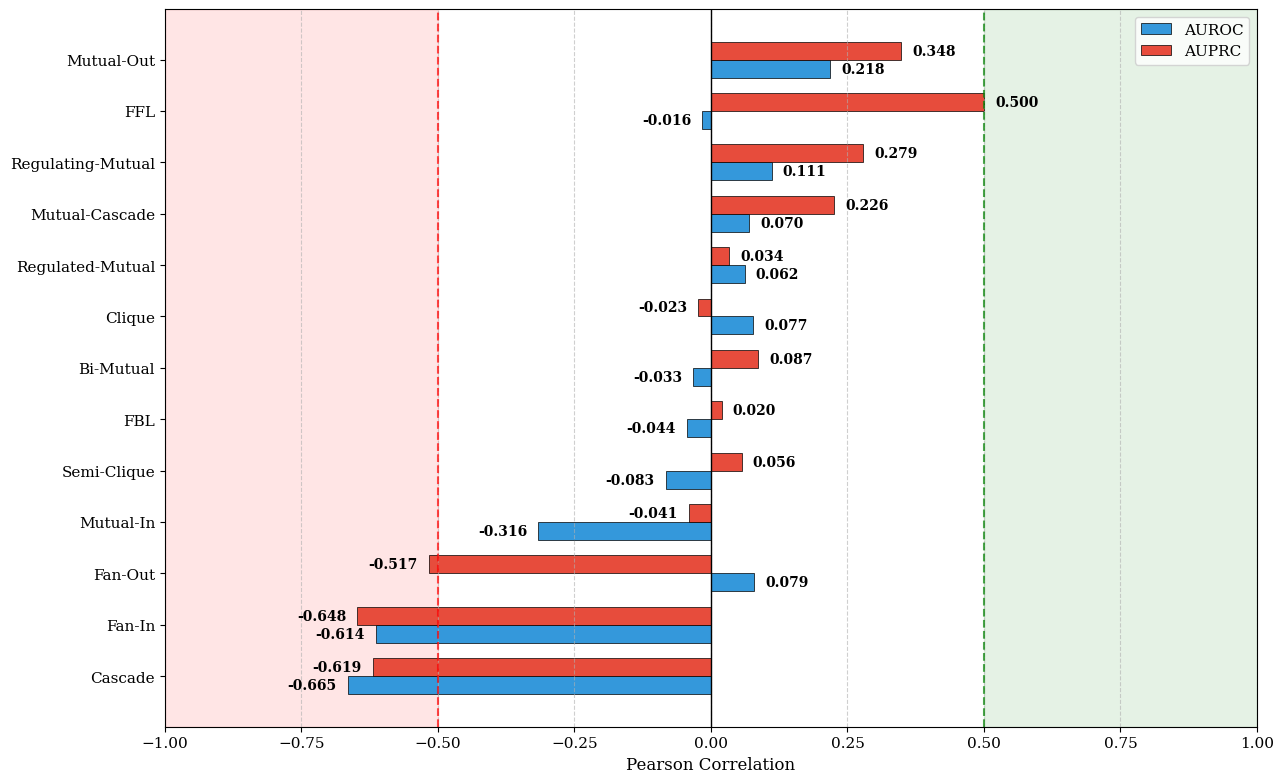

In [8]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'text.usetex': False,
})

# Sort by average effect (AUROC + AUPRC) to highlight most impactful motifs
avg_effect = {k: (auroc_pearson[k] + auprc_pearson[k]) / 2 for k in auroc_pearson}
sorted_motifs = sorted(avg_effect.keys(), key=lambda x: avg_effect[x])

auroc_values = [auroc_pearson[m] for m in sorted_motifs]
auprc_values = [auprc_pearson[m] for m in sorted_motifs]

# Plot - increased size (wider + 15% taller)
fig, ax = plt.subplots(figsize=(13, 8))

THRESHOLD = 0.5

# Add shaded regions for significant correlations
ax.axvspan(-1, -THRESHOLD, alpha=0.1, color='red')
ax.axvspan(THRESHOLD, 1, alpha=0.1, color='green')

y = np.arange(len(sorted_motifs))
height = 0.35

bars1 = ax.barh(y - height/2, auroc_values, height, label='AUROC', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.barh(y + height/2, auprc_values, height, label='AUPRC', color='#e74c3c', edgecolor='black', linewidth=0.5)

# Add values on bars (10pt for bar labels)
def add_bar_labels(bars, values):
    for bar, val in zip(bars, values):
        if val >= 0:
            x_pos = bar.get_width() + 0.02
            ha = 'left'
        else:
            x_pos = bar.get_width() - 0.02
            ha = 'right'
        
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')

add_bar_labels(bars1, auroc_values)
add_bar_labels(bars2, auprc_values)

# Zero line
ax.axvline(x=0, color='black', linewidth=1)

# Threshold lines at ±0.5
ax.axvline(x=THRESHOLD, color='green', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(x=-THRESHOLD, color='red', linewidth=1.5, linestyle='--', alpha=0.7)

ax.set_yticks(y)
ax.set_yticklabels(sorted_motifs)
ax.set_xlabel('Pearson Correlation')
# ax.set_title('Effect of Motif Frequency on Model Performance', fontweight='bold')
ax.legend(loc='upper right')

# X-axis from -1 to 1
ax.set_xlim(-1, 1)

# Add gridlines for readability
ax.xaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# plt.savefig('motif_grouped_comparison.png', dpi=300, bbox_inches='tight')
# plt.savefig('motif_grouped_comparison.pdf', dpi=300, bbox_inches='tight')
save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}sensitivity_AUPRC_AUROC_grouped.png', 'png')
save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}sensitivity_AUPRC_AUROC_grouped.pdf', 'pdf')
save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}sensitivity_AUPRC_AUROC_grouped.svg', 'svg')
# plt.savefig(f'{OUTPUT_FIGURE_PATH}sensitivity_AUPRC_AUROC_grouped.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'{OUTPUT_FIGURE_PATH}sensitivity_AUPRC_AUROC_grouped.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{OUTPUT_FIGURE_PATH}sensitivity_AUPRC_AUROC_grouped.svg', dpi=300, bbox_inches='tight')
plt.show()

# Reset to default after plotting (optional)
plt.rcParams.update(plt.rcParamsDefault)

# Plot EPRC pearson correlation change with motif counts

Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_auroc_comparison.png
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_auroc_comparison.pdf
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_auroc_comparison.svg


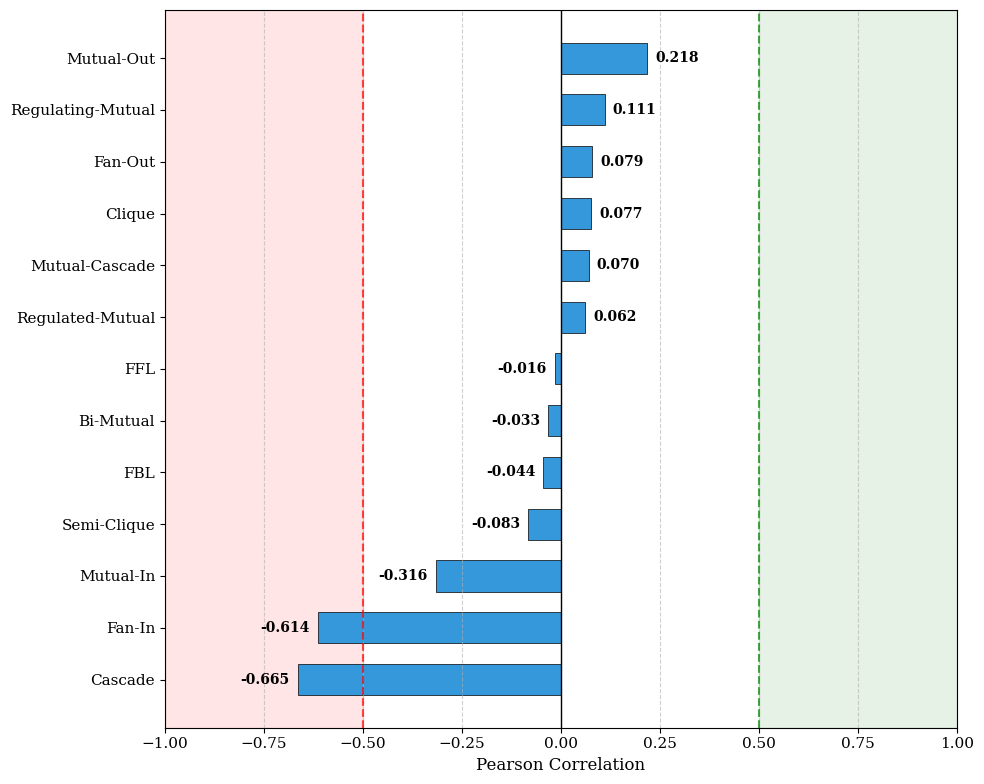

Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_auprc_comparison.png
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_auprc_comparison.pdf
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_auprc_comparison.svg


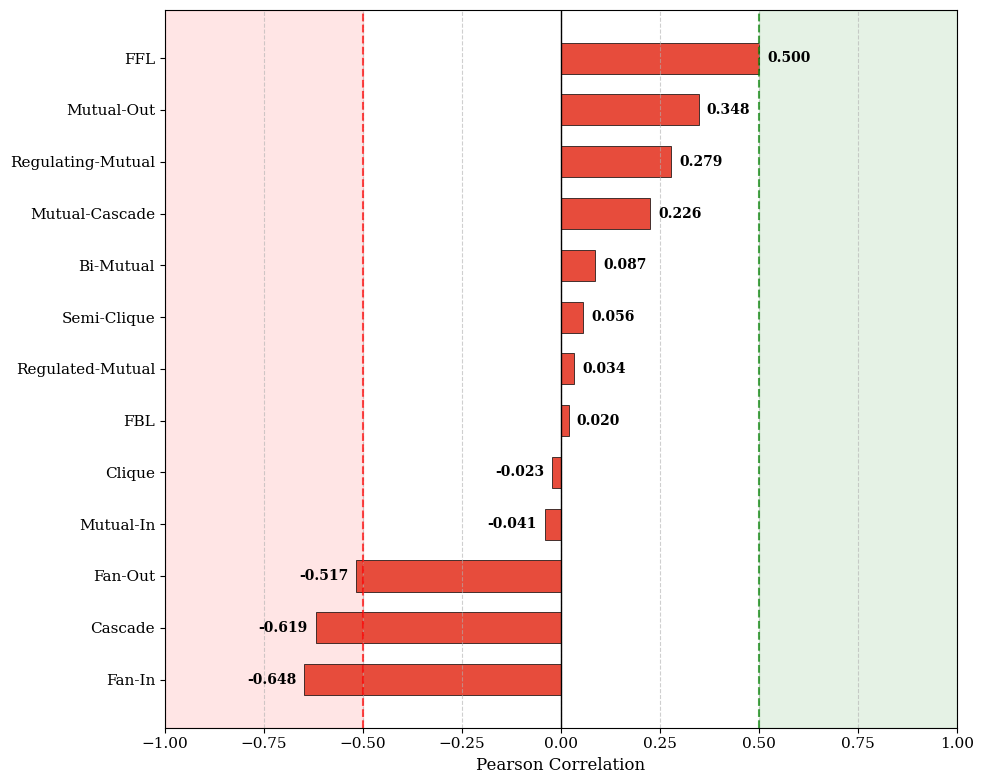

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Set up LaTeX-style fonts (12pt base)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'text.usetex': False,
})

THRESHOLD = 0.5


def plot_single_metric(data_dict, metric_name, color, OUTPUT_FIGURE_PATH, filename):
    """Plot a single metric with its own sorting and save to separate file."""
    
    # Create a new figure for each plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sort by raw value
    sorted_motifs = sorted(data_dict.keys(), key=lambda x: data_dict[x])
    values = [data_dict[m] for m in sorted_motifs]
    
    # Add shaded regions for significant correlations
    ax.axvspan(-1, -THRESHOLD, alpha=0.1, color='red')
    ax.axvspan(THRESHOLD, 1, alpha=0.1, color='green')
    
    y = np.arange(len(sorted_motifs))
    height = 0.6
    
    bars = ax.barh(y, values, height, color=color, edgecolor='black', linewidth=0.5)
    
    # Add values on bars
    for bar, val in zip(bars, values):
        if val >= 0:
            x_pos = bar.get_width() + 0.02
            ha = 'left'
        else:
            x_pos = bar.get_width() - 0.02
            ha = 'right'
        
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')
    
    # Zero line
    ax.axvline(x=0, color='black', linewidth=1)
    
    # Threshold lines at ±0.5
    ax.axvline(x=THRESHOLD, color='green', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.axvline(x=-THRESHOLD, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
    
    ax.set_yticks(y)
    ax.set_yticklabels(sorted_motifs)
    ax.set_xlabel('Pearson Correlation')
    # ax.set_title(f'{metric_name}', fontweight='bold')
    ax.set_xlim(-1, 1)
    ax.xaxis.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    # plt.savefig(f'{OUTPUT_FIGURE_PATH}{filename}.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{OUTPUT_FIGURE_PATH}{filename}.pdf', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{OUTPUT_FIGURE_PATH}{filename}.svg', dpi=300, bbox_inches='tight')
    save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}{filename}.png', 'png')
    save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}{filename}.pdf', 'pdf')
    save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}{filename}.svg', 'svg')
    plt.show()


# Create two separate plots
plot_single_metric(auroc_pearson, 'AUROC', '#3498db', OUTPUT_FIGURE_PATH,'motif_auroc_comparison')
plot_single_metric(auprc_pearson, 'AUPRC', '#e74c3c', OUTPUT_FIGURE_PATH,'motif_auprc_comparison')

# Reset to default after plotting
plt.rcParams.update(plt.rcParamsDefault)

Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_epr_comparison.png
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_epr_comparison.pdf
Saved: gs://aetl_sur-axe-workspace-prod-db34/data/sensitivity_analysis/figures/motif_epr_comparison.svg


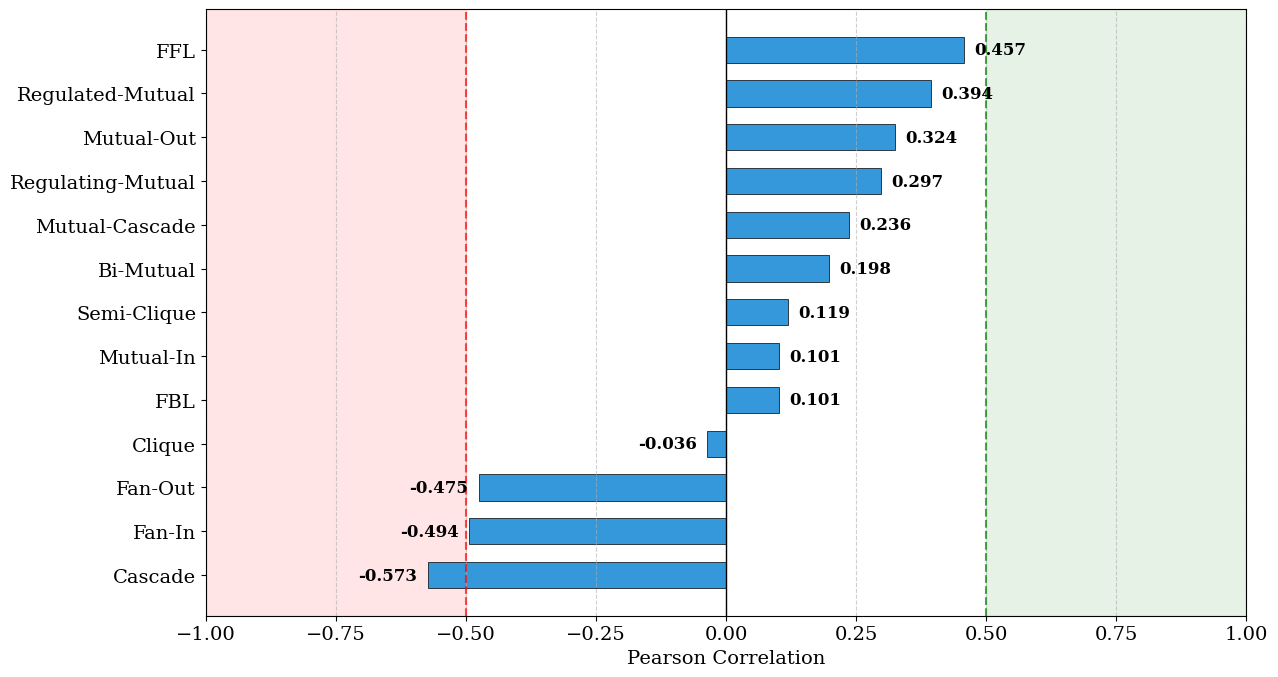

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# Set up LaTeX-style fonts (12pt base)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 11,
    'text.usetex': False,
})

# Sort by EPR value
sorted_motifs = sorted(epr_pearson.keys(), key=lambda x: epr_pearson[x])
epr_values = [epr_pearson[m] for m in sorted_motifs]
# Plot - slightly reduced height since only one metric
fig, ax = plt.subplots(figsize=(13, 7))
THRESHOLD = 0.5
# Add shaded regions for significant correlations
ax.axvspan(-1, -THRESHOLD, alpha=0.1, color='red')
ax.axvspan(THRESHOLD, 1, alpha=0.1, color='green')
y = np.arange(len(sorted_motifs))
height = 0.6 # Increased bar height for single metric
# Single bar chart for EPR
bars = ax.barh(y, epr_values, height, label='EPR', color='#3498db', 
edgecolor='black', linewidth=0.5)
# Add values on bars
def add_bar_labels(bars, values):
    for bar, val in zip(bars, values):
        if val >= 0:
            x_pos = bar.get_width() + 0.02
            ha = 'left'
        else:
            x_pos = bar.get_width() - 0.02
            ha = 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', ha=ha, fontsize=12, 
            fontweight='bold')
add_bar_labels(bars, epr_values)
# Zero line
ax.axvline(x=0, color='black', linewidth=1)
# Threshold lines at ±0.5
ax.axvline(x=THRESHOLD, color='green', linewidth=1.5, linestyle='--', 
    alpha=0.7)
ax.axvline(x=-THRESHOLD, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_yticks(y)
ax.set_yticklabels(sorted_motifs)
ax.set_xlabel('Pearson Correlation')
# X-axis from -1 to 1
ax.set_xlim(-1, 1)
# Add gridlines for readability
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig(f'{OUTPUT_FILE_PATH}motif_epr_comparison.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'{OUTPUT_FILE_PATH}motif_epr_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{OUTPUT_FILE_PATH}motif_epr_comparison.svg', dpi=300, bbox_inches='tight')
save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}motif_epr_comparison.png', 'png')
save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}motif_epr_comparison.pdf', 'pdf')
save_fig_to_gcs(fig, f'{OUTPUT_FIGURE_PATH}motif_epr_comparison.svg', 'svg')
plt.show()
# Reset to default after plotting
plt.rcParams.update(plt.rcParamsDefault)

# End